# PTP1B activity 

<div style="display:flex; gap:20px; align-items:flex-start;">

<div style="flex:2;">
<h3>Project Overview</h3>
<ul>
  <li>Protein–ligand binding</li>
  <li>Rotating PDB structure</li>
  <li>Visualization for reporting</li>
</ul>
</div>

<div style="flex:1; text-align:right;">
<img src="..\data\1aax.gif" width="500">
</div>

</div>


In [54]:
import pandas as pd
import numpy as np

# -- Visualization --
import matplotlib.pyplot as plt

# -- RDKit --
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.MolStandardize import rdMolStandardize


# -- Model Evalution --
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv(r'..\data\ptp1b_data.csv', delimiter=';')

In [4]:
df = df[df['Standard Value'].notna()]

In [5]:
df.head(2)

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units,pChEMBL Value,Data Validity Comment,Comment,Uo Units,Ligand Efficiency BEI,Ligand Efficiency LE,Ligand Efficiency LLE,Ligand Efficiency SEI,Potential Duplicate,Assay ChEMBL ID,Assay Description,Assay Type,BAO Format ID,BAO Label,Assay Organism,Assay Tissue ChEMBL ID,Assay Tissue Name,Assay Cell Type,Assay Subcellular Fraction,Assay Parameters,Assay Variant Accession,Assay Variant Mutation,Target ChEMBL ID,Target Name,Target Organism,Target Type,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL264833,NaN,NaN,611.71,1.0,4.25,50,N#Cc1ccc2[nH]c(C(Cc3ccc(C4CC(=O)NS4(=O)=O)cc3)...,IC50,'=',53.0,nM,7.28,NaN,NaN,UO_0000065,11.89,0.23,3.03,4.49,0,CHEMBL870503,Inhibition of PTP1B by pNPP assay,B,BAO_0000357,single protein format,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL335,Tyrosine-protein phosphatase non-receptor type 1,Homo sapiens,SINGLE PROTEIN,CHEMBL1138056,1,Scientific Literature,J Med Chem,2006,NaN,NaN,NaN,NaN,53.0
1,CHEMBL223067,NaN,NaN,292.29,0.0,4.21,8b,COc1ccc(-c2cc(=O)c3cc4ccoc4cc3o2)cc1,IC50,'=',68800.0,nM,4.16,NaN,NaN,UO_0000065,14.24,0.26,-0.05,7.92,0,CHEMBL918283,Inhibition of PTP1B in presence of 0.01% Trito...,B,BAO_0000357,single protein format,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL335,Tyrosine-protein phosphatase non-receptor type 1,Homo sapiens,SINGLE PROTEIN,CHEMBL1144560,1,Scientific Literature,Bioorg Med Chem,2007,NaN,NaN,NaN,NaN,68.8


In [6]:
df['Standard Units'].value_counts()

Standard Units
nM          4533
ug.mL-1       77
10'20 uM       1
Name: count, dtype: int64

In [7]:
df.drop(df[df['Standard Units']=="10'20 uM"].index, inplace=True)

In [8]:
mask = df['Standard Units'] == 'ug.mL-1'
df.loc[mask, 'Standard Value'] = (df.loc[mask, 'Standard Value'] * 1e6 / df.loc[mask, 'Molecular Weight'])
df.loc[mask, 'Standard Units'] = 'nM'

In [9]:
df['Standard Units'].value_counts()

Standard Units
nM    4610
Name: count, dtype: int64

In [10]:
def identify_duplicates(df, smiles_column):
    """Identifies duplicate molecules in a dataset using SMILES strings."""
    def standardize_smiles(smiles):
        """Standardize SMILES to canonical form"""
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return None
            return Chem.MolToSmiles(mol, canonical=True)
        except:
            return None

    def calculate_inchi_key(smiles):
        """Calculate InChI Key for a SMILES string"""
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return None
            return Chem.MolToInchiKey(mol)
        except:
            return None

    # Create a copy of the dataframe
    df_analysis = df.copy()

    # Add standardized SMILES
    df_analysis['canonical_smiles'] = df_analysis[smiles_column].apply(standardize_smiles)

    # Add InChI Keys
    df_analysis['inchi_key'] = df_analysis['canonical_smiles'].apply(calculate_inchi_key)

    # Mark invalid SMILES
    df_analysis['is_valid'] = df_analysis['canonical_smiles'].notna()

    # Identify duplicates
    df_analysis['is_duplicate'] = df_analysis['inchi_key'].duplicated(keep='first')

    # Group duplicates
    df_analysis['duplicate_group'] = df_analysis.groupby('inchi_key').ngroup()

    # Count occurrences of each molecule
    duplicate_counts = df_analysis['inchi_key'].value_counts()
    df_analysis['occurrence_count'] = df_analysis['inchi_key'].map(duplicate_counts)

    return df_analysis

def get_duplicate_summary(df_analysis):
    """Generates a summary of duplicate analysis"""
    summary = {
        'total_molecules': len(df_analysis),
        'invalid_smiles': (~df_analysis['is_valid']).sum(),
        'unique_molecules': df_analysis['inchi_key'].nunique(),
        'duplicate_molecules': df_analysis['is_duplicate'].sum(),
        'molecules_with_duplicates': len(df_analysis[df_analysis['occurrence_count'] > 1]),
        'max_duplicates': df_analysis['occurrence_count'].max()
    }
    return summary



In [11]:
df_analyzed = identify_duplicates(df, 'Smiles')
df_analyzed.head(1)

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units,pChEMBL Value,Data Validity Comment,Comment,Uo Units,Ligand Efficiency BEI,Ligand Efficiency LE,Ligand Efficiency LLE,Ligand Efficiency SEI,Potential Duplicate,Assay ChEMBL ID,Assay Description,Assay Type,BAO Format ID,BAO Label,Assay Organism,Assay Tissue ChEMBL ID,Assay Tissue Name,Assay Cell Type,Assay Subcellular Fraction,Assay Parameters,Assay Variant Accession,Assay Variant Mutation,Target ChEMBL ID,Target Name,Target Organism,Target Type,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value,canonical_smiles,inchi_key,is_valid,is_duplicate,duplicate_group,occurrence_count
0,CHEMBL264833,NaN,NaN,611.71,1.0,4.25,50,N#Cc1ccc2[nH]c(C(Cc3ccc(C4CC(=O)NS4(=O)=O)cc3)...,IC50,'=',53.0,nM,7.28,NaN,NaN,UO_0000065,11.89,0.23,3.03,4.49,0,CHEMBL870503,Inhibition of PTP1B by pNPP assay,B,BAO_0000357,single protein format,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL335,Tyrosine-protein phosphatase non-receptor type 1,Homo sapiens,SINGLE PROTEIN,CHEMBL1138056,1,Scientific Literature,J Med Chem,2006,NaN,NaN,NaN,NaN,53.0,N#Cc1ccc2[nH]c(C(Cc3ccc(C4CC(=O)NS4(=O)=O)cc3)...,MVJVTJMEHPNMCJ-UHFFFAOYSA-N,True,False,1899.0,1.0


In [12]:
summary = get_duplicate_summary(df_analyzed)
summary

{'total_molecules': 4610,
 'invalid_smiles': np.int64(27),
 'unique_molecules': 3913,
 'duplicate_molecules': np.int64(696),
 'molecules_with_duplicates': 1100,
 'max_duplicates': np.float64(51.0)}

In [13]:
def process_duplicates(df, inchi_key_col, pchembl_col):
    """Process duplicates with different handling for zero-SD and non-zero-SD groups."""
    # Create working copy
    df_work = df.copy()

    # Calculate group statistics
    group_stats = df_work.groupby(inchi_key_col).agg({
        pchembl_col: ['count', 'mean', 'std']
    }).round(4)

    group_stats.columns = ['count', 'mean', 'std']
    group_stats = group_stats.reset_index()

    # Filter for groups with multiple entries
    duplicate_groups = group_stats[group_stats['count'] > 1].copy()
    # Identify single entry compounds
    single_entry_groups = group_stats[group_stats['count'] == 1].copy()

    # Initialize list for processed rows and duplicates info
    processed_rows = []
    compounds_with_dups = []

    # Process each group
    for inchi_key in group_stats['inchi_key']:
        group_data = df_work[df_work[inchi_key_col] == inchi_key].copy()
        group_stats_row = group_stats[group_stats['inchi_key'] == inchi_key].iloc[0]

        if len(group_data) > 1:  # Multiple entries
            # Add statistics to group data
            group_data['group_mean'] = group_stats_row['mean']
            group_data['group_std'] = group_stats_row['std']
            compounds_with_dups.append(group_data)

            if group_stats_row['std'] == 0:  # Zero-SD group
                # Keep only the first row for zero-SD groups
                processed_row = group_data.iloc[[0]].copy()
                processed_row['group_type'] = 'zero_sd'
            else:  # Non-zero-SD group
                # Keep first row but update pChEMBL value with mean
                processed_row = group_data.iloc[[0]].copy()
                processed_row[pchembl_col] = group_stats_row['mean']
                processed_row['group_type'] = 'nonzero_sd'

            processed_rows.append(processed_row)

        else:  # Single entry
            group_data['group_type'] = 'single_entry'
            processed_rows.append(group_data)

    # Combine all processed rows
    final_df = pd.concat(processed_rows)
    compounds_with_duplicates_df = pd.concat(compounds_with_dups) if compounds_with_dups else pd.DataFrame()

    # Create summary
    summary_stats = {
        'total_initial_compounds': len(df),
        'total_unique_inchikeys': len(group_stats),
        'single_entry_compounds': len(single_entry_groups),
        'compounds_with_duplicates': len(duplicate_groups),
        'zero_sd_groups': len(duplicate_groups[duplicate_groups['std'] == 0]),
        'nonzero_sd_groups': len(duplicate_groups[duplicate_groups['std'] > 0]),
        'final_compounds': len(final_df)
    }

    summary_df = pd.DataFrame([summary_stats]).transpose()
    summary_df.columns = ['count']

    # Sort final DataFrame by InChI key
    final_df = final_df.sort_values(by=[inchi_key_col])

    return final_df, summary_df, compounds_with_duplicates_df
    

In [14]:
final_df, summary_df, compounds_with_dups_df = process_duplicates(
    df_analyzed,
    inchi_key_col='inchi_key',
    pchembl_col='Standard Value'
)

In [15]:
summary_df

,count
total_initial_compounds,4610
total_unique_inchikeys,3913
single_entry_compounds,3483
compounds_with_duplicates,430
zero_sd_groups,137
nonzero_sd_groups,293
final_compounds,3913


In [16]:
final_df.group_type.value_counts()

group_type
single_entry    3483
nonzero_sd       293
zero_sd          137
Name: count, dtype: int64

In [17]:
final_df.shape

(3913, 57)

In [18]:
final_df.columns

Index(['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase',
       'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key',
       'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value',
       'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment',
       'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE',
       'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate',
       'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID',
       'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID',
       'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction',
       'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation',
       'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type',
       'Document ChEMBL ID', 'Source ID', 'Source Description',
       'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties',
       'Action Type', 'Standard Text Value', 'V

In [19]:
df = final_df[['Smiles', 'Standard Value']]
df = final_df[(~(final_df['Standard Value'].isna()) & ~(final_df['Smiles'].isna()))]
df = final_df[final_df['Standard Value']>0]

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3913 entries, 1700 to 3819
Data columns (total 57 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          3913 non-null   object 
 1   Molecule Name               288 non-null    object 
 2   Molecule Max Phase          32 non-null     float64
 3   Molecular Weight            3913 non-null   float64
 4   #RO5 Violations             3858 non-null   float64
 5   AlogP                       3858 non-null   float64
 6   Compound Key                3913 non-null   object 
 7   Smiles                      3913 non-null   object 
 8   Standard Type               3913 non-null   object 
 9   Standard Relation           3913 non-null   object 
 10  Standard Value              3913 non-null   float64
 11  Standard Units              3913 non-null   object 
 12  pChEMBL Value               3066 non-null   float64
 13  Data Validity Comment       418 non

In [21]:
def activity(value):
    if value <= 1000:
        return 1 # active
    elif value > 10000:
        return 0
    else:
        return np.nan
df['activity'] = df['Standard Value'].apply(activity)

In [22]:
df.dropna(subset=['activity'], inplace=True)

In [23]:
df.activity.value_counts()

activity
0.0    1890
1.0     688
Name: count, dtype: int64

In [24]:
def is_salt(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    frags = Chem.GetMolFrags(mol, asMols=True)
    return len(frags) > 1

df['is_salt'] = df['Smiles'].apply(is_salt)

In [25]:
def no_salt_calculate(df):
    total_salt_compounds = df['is_salt'].sum()
    total_active_salt_compounds = df.loc[df['is_salt'], ['activity']].sum()
    print(f'The total salts compounds are {total_salt_compounds}, from which {int(total_active_salt_compounds.iloc[0])} are active compounds!')
    
no_salt_calculate(df)

The total salts compounds are 73, from which 19 are active compounds!


In [26]:
salts_index = df.loc[df['is_salt']==True, 'Smiles'].index

def get_parent_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    remover = rdMolStandardize.FragmentRemover()
    parent = remover.remove(mol)
    return Chem.MolToSmiles(parent, canonical=True)

df.loc[salts_index, 'Smiles'] = (df.loc[salts_index, 'Smiles'].apply(get_parent_smiles))

[16:56:11] Running FragmentRemover
[16:56:11] Removed fragment: ammonia/ammonium
[16:56:11] Running FragmentRemover
[16:56:11] Removed fragment: sodium
[16:56:11] Running FragmentRemover
[16:56:11] Removed fragment: ammonia/ammonium
[16:56:11] Running FragmentRemover
[16:56:11] Removed fragment: ammonia/ammonium
[16:56:11] Running FragmentRemover
[16:56:11] Removed fragment: sodium
[16:56:11] Running FragmentRemover
[16:56:11] Removed fragment: sodium
[16:56:11] Running FragmentRemover
[16:56:11] Removed fragment: sodium
[16:56:11] Running FragmentRemover
[16:56:11] Removed fragment: sodium
[16:56:11] Running FragmentRemover
[16:56:11] Removed fragment: sodium
[16:56:11] Running FragmentRemover
[16:56:11] Removed fragment: sodium
[16:56:11] Running FragmentRemover
[16:56:11] Removed fragment: sodium
[16:56:11] Running FragmentRemover
[16:56:11] Removed fragment: sodium
[16:56:11] Running FragmentRemover
[16:56:11] Removed fragment: sodium
[16:56:11] Running FragmentRemover
[16:56:11] R

In [27]:
df['is_salt'] = df['Smiles'].apply(is_salt)
no_salt_calculate(df)

The total salts compounds are 4, from which 3 are active compounds!


In [28]:
df = df.drop_duplicates(subset='Smiles')
df.shape

(2575, 59)

In [29]:
df['activity'].value_counts()

activity
0.0    1887
1.0     688
Name: count, dtype: int64

In [30]:
df['Smiles'].value_counts().head()

Smiles
O=C(O)COc1ccc(S(=O)(=O)N(Cc2ccc(C(F)(F)P(=O)(O)O)cc2)Cc2cccs2)cc1                                          1
COC(CC(C)C)c1ccc2ccc(-c3ccc(CC(Cc4ccc(C(F)(F)P(=O)(O)O)cc4)(c4ccccc4)n4nnc5ccccc54)cc3)c(P(=O)(O)O)c2n1    1
O=C1Nc2ccc(S(=O)(=O)NCc3ccc(F)cc3)cc2/C1=N/Nc1cccc(C(=O)O)c1                                               1
Cc1ccc(S(=O)(=O)N(Cc2ccc(C(=O)C(F)(F)P(=O)(O)O)cc2)Cc2ccc(C(=O)C(F)(F)P(=O)(O)O)cc2)cc1                    1
O=C(O)c1cc2ccccc2oc1=O                                                                                     1
Name: count, dtype: int64

In [31]:
df['is_salt'] = df['Smiles'].apply(is_salt)
no_salt_calculate(df)

The total salts compounds are 4, from which 3 are active compounds!


In [32]:
def generate_fingerprints(smiles):

    morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)
    try:
        # 1. Safely create and sanitize molecule
        mol = Chem.MolFromSmiles(smiles, sanitize=True)
        if mol is None:
            raise ValueError("Invalid SMILES")

        # 2. Remove explicit hydrogens (fixes H-without-neighbors warning)
        mol = Chem.RemoveHs(mol)

        # 3. Calculate descriptors (same as before)
        return pd.Series({'fp': morgan_gen.GetFingerprint(mol)})

    except Exception:
        # 4. Fail safely (same NaN structure as original)
        return pd.Series({'fp': np.nan})

descriptor_cols = df['Smiles'].apply(generate_fingerprints)

df = pd.concat([df, descriptor_cols], axis=1)

print(f"Failed rows: {df['Smiles'].isna().sum()}")

Failed rows: 0


In [33]:
df.head(2)

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units,pChEMBL Value,Data Validity Comment,Comment,Uo Units,Ligand Efficiency BEI,Ligand Efficiency LE,Ligand Efficiency LLE,Ligand Efficiency SEI,Potential Duplicate,Assay ChEMBL ID,Assay Description,Assay Type,BAO Format ID,BAO Label,Assay Organism,Assay Tissue ChEMBL ID,Assay Tissue Name,Assay Cell Type,Assay Subcellular Fraction,Assay Parameters,Assay Variant Accession,Assay Variant Mutation,Target ChEMBL ID,Target Name,Target Organism,Target Type,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value,canonical_smiles,inchi_key,is_valid,is_duplicate,duplicate_group,occurrence_count,group_type,group_mean,group_std,activity,is_salt,fp
2838,CHEMBL197929,NaN,NaN,547.49,1.0,3.83,19,O=C(O)COc1ccc(S(=O)(=O)N(Cc2ccc(C(F)(F)P(=O)(O...,IC50,'=',1000.0,nM,6.0,NaN,NaN,UO_0000065,10.96,0.23,2.17,4.24,0,CHEMBL880579,Inhibitory activity against protein tyrosine p...,B,BAO_0000357,single protein format,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL335,Tyrosine-protein phosphatase non-receptor type 1,Homo sapiens,SINGLE PROTEIN,CHEMBL1141064,1,Scientific Literature,Bioorg Med Chem Lett,2005,NaN,NaN,NaN,NaN,1.0,O=C(O)COc1ccc(S(=O)(=O)N(Cc2ccc(C(F)(F)P(=O)(O...,ABDQNRCWGSGNBQ-UHFFFAOYSA-N,True,False,4.0,1.0,single_entry,NaN,NaN,1.0,False,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
4316,CHEMBL4542052,NaN,NaN,826.77,2.0,8.64,"Fig 2, cpd d",COC(CC(C)C)c1ccc2ccc(-c3ccc(CC(Cc4ccc(C(F)(F)P...,IC50,'=',5.0,nM,8.3,NaN,NaN,UO_0000065,10.04,0.20,-0.34,4.94,0,CHEMBL4434240,Inhibition of human FLAG-tagged PTP1B catalyti...,B,BAO_0000019,assay format,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL335,Tyrosine-protein phosphatase non-receptor type 1,Homo sapiens,SINGLE PROTEIN,CHEMBL4433240,1,Scientific Literature,Bioorg Med Chem Lett,2019,NaN,NaN,NaN,NaN,5.0,COC(CC(C)C)c1ccc2ccc(-c3ccc(CC(Cc4ccc(C(F)(F)P...,ABRZBKRUFDGIHD-UHFFFAOYSA-N,True,False,5.0,1.0,single_entry,NaN,NaN,1.0,False,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [34]:
def to_array(fp):
    arr = np.zeros(fp.GetNumBits(), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr
fp_array = df['fp'].apply(to_array)

df['fp'] = fp_array

In [35]:
df.columns

Index(['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase',
       'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key',
       'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value',
       'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment',
       'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE',
       'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate',
       'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID',
       'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID',
       'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction',
       'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation',
       'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type',
       'Document ChEMBL ID', 'Source ID', 'Source Description',
       'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties',
       'Action Type', 'Standard Text Value', 'V

In [36]:
X = np.stack(df['fp'])
y = df['activity']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
X_train.shape

(2060, 2048)

In [69]:
models = {'SVC': SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42, probability=True),
          'RF': RandomForestClassifier(), 
          'XGB': XGBClassifier(random_state=42),
          'LGBM': LGBMClassifier(random_state=42, verbose=-1, force_col_wise=True),
          'Naive Bayes': MultinomialNB(alpha=1),
          'Logistic Regression': LogisticRegression()}

In [70]:
for name, model in models.items():
    print ('='*60)
    print(f'By {name}')

    model = model

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    cm = confusion_matrix(y_test, y_pred)
    print(classification_report(y_test, y_pred))
    print(f'CM Score:\n{cm}')

    y_prob = model.predict_proba(X_test)[:, 1]
    # ROC-AUC
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC: {roc_auc:.3f}")

    # PR-AUC
    pr_auc = average_precision_score(y_test, y_prob)
    print(f"PR-AUC : {pr_auc:.3f}")


By SVC
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97       377
         1.0       0.95      0.86      0.90       138

    accuracy                           0.95       515
   macro avg       0.95      0.92      0.94       515
weighted avg       0.95      0.95      0.95       515

CM Score:
[[371   6]
 [ 19 119]]
ROC-AUC: 0.969
PR-AUC : 0.956
By RF
              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95       377
         1.0       0.95      0.77      0.85       138

    accuracy                           0.93       515
   macro avg       0.93      0.88      0.90       515
weighted avg       0.93      0.93      0.92       515

CM Score:
[[371   6]
 [ 32 106]]
ROC-AUC: 0.967
PR-AUC : 0.950
By XGB
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96       377
         1.0       0.94      0.85      0.89       138

    accuracy                        

By SVC:
The best threshold is 0.39090831464780024
While the best tpr is 0.9130434782608695
The best fpr is 0.01856763925729443

--- Default Threshold (0.5) ---
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97       377
         1.0       0.95      0.86      0.90       138

    accuracy                           0.95       515
   macro avg       0.95      0.92      0.94       515
weighted avg       0.95      0.95      0.95       515

CM:
[[371   6]
 [ 19 119]]

--- Custom Threshold (0.39090831464780024) ---
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97       377
         1.0       0.95      0.91      0.93       138

    accuracy                           0.96       515
   macro avg       0.96      0.95      0.95       515
weighted avg       0.96      0.96      0.96       515

CM:
[[370   7]
 [ 12 126]]

ROC-AUC: 0.969
PR-AUC : 0.956


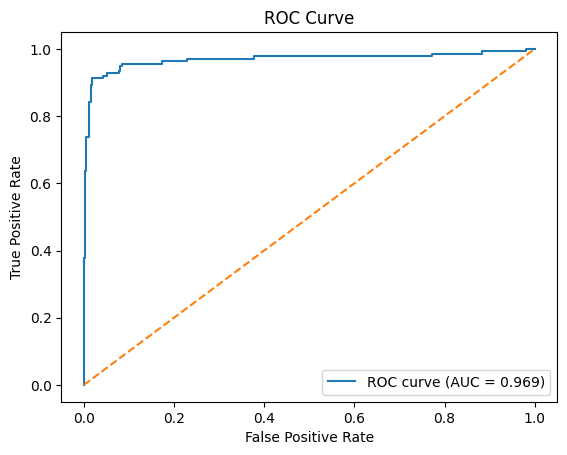

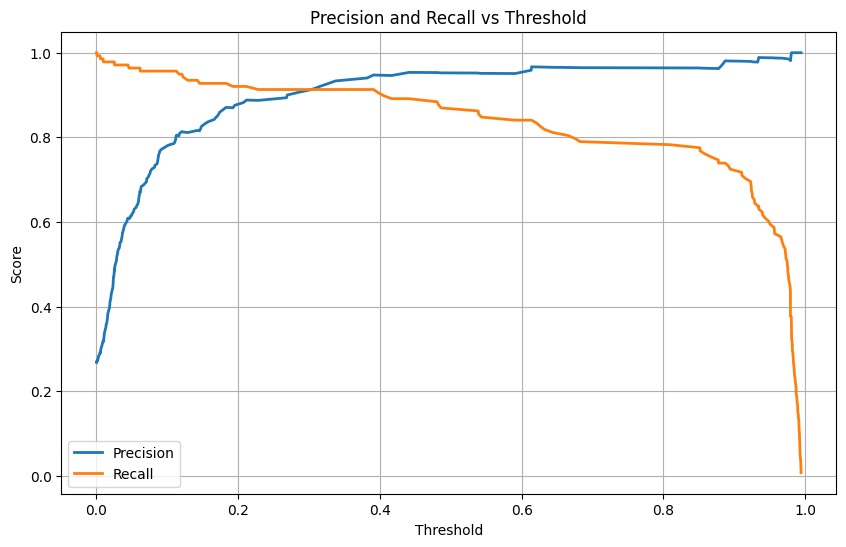

In [77]:
print('By SVC:')

model = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42, probability=True)

# Train the model
model.fit(X_train, y_train)

# Get probability scores
y_prob = model.predict_proba(X_test)[:, 1]

# Default threshold (0.5)
y_pred_default = model.predict(X_test)

y_prob = y_prob            # The probabilties from our best classification model (i.e. SVC)

fpr, tpr, threshold = roc_curve(y_test, y_prob)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)

best_threshold = threshold[best_idx]
best_tpr = tpr[best_idx]
best_fpr = fpr[best_idx]

print(f'The best threshold is {best_threshold}\nWhile the best tpr is {best_tpr}\nThe best fpr is {best_fpr}')


# Custom threshold - try different values
threshold = best_threshold  # Best threshold from above

y_pred_custom = (y_prob >= threshold).astype(int)

# Compare results
print(f"\n--- Default Threshold (0.5) ---")
cm_default = confusion_matrix(y_test, y_pred_default)
print(classification_report(y_test, y_pred_default))
print(f'CM:\n{cm_default}')

print(f"\n--- Custom Threshold ({threshold}) ---")
cm_custom = confusion_matrix(y_test, y_pred_custom)
print(classification_report(y_test, y_pred_custom))
print(f'CM:\n{cm_custom}')

# ROC-AUC (doesn't change with threshold)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC: {roc_auc:.3f}")

# PR-AUC (doesn't change with threshold)
pr_auc = average_precision_score(y_test, y_prob)
print(f"PR-AUC : {pr_auc:.3f}")


plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


# Get precision-recall curve
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_prob)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds_pr, precisions[:-1], label='Precision', linewidth=2)
plt.plot(thresholds_pr, recalls[:-1], label='Recall', linewidth=2)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()
